# **News Category**

News headline categorization with fine-tuned DistilBERT, BiLSTM, logistic regression, and Naive Bayes.

## **Preprocessing**

Profiles the raw dataset, cleans it, and writes one stratified train/test split to `data/processed/base/`. The split is stratified on the full raw category set, since merging is handled later.

Outputs (under `data/processed/base/`):

- `train.parquet` — training split; holds the cross-validation pool

- `test.parquet` — held-out split; touched once at the end

### **Setup**


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from pathlib import Path
from news_category.display import show

pd.set_option("display.max_rows", 100)
sns.set_theme(context="notebook", style="whitegrid")
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["figure.titlesize"] = 16
plt.rcParams["figure.titleweight"] = "bold"

RANDOM_STATE = 42
TEST_SIZE = 0.2

FILE_RAW = Path("data/raw/News_Category_Dataset_v3.json")
DIR_BASE = Path("data/processed/base")
DIR_BASE.mkdir(parents=True, exist_ok=True)

# default df.head() to 10 rows
_orig_head = pd.DataFrame.head
pd.DataFrame.head = lambda self, n=10: _orig_head(self, n)

### **Discovery**

#### **Load**


In [2]:
df_raw = pd.read_json(FILE_RAW, lines=True).assign(date=lambda d: pd.to_datetime(d["date"]))[
  ["category", "headline", "short_description", "authors", "date", "link"]
]
show("Preview (RAW)", df_raw.head())

df_summary_raw = df_raw.describe(include="all").T
df_summary_raw.insert(0, "dtype", df_raw.dtypes)
show("Summary (RAW)", df_summary_raw.head())

── Preview (RAW) ───────────────────────────


,category,headline,short_description,authors,date,link
0,U.S. NEWS,Over 4 Million Americans Roll Up Sleeves For O...,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23,https://www.huffpost.com/entry/covid-boosters-...
1,U.S. NEWS,"American Airlines Flyer Charged, Banned For Li...",He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23,https://www.huffpost.com/entry/american-airlin...
2,COMEDY,23 Of The Funniest Tweets About Cats And Dogs ...,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23,https://www.huffpost.com/entry/funniest-tweets...
3,PARENTING,The Funniest Tweets From Parents This Week (Se...,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23,https://www.huffpost.com/entry/funniest-parent...
4,U.S. NEWS,Woman Who Called Cops On Black Bird-Watcher Lo...,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22,https://www.huffpost.com/entry/amy-cooper-lose...
5,U.S. NEWS,Cleaner Was Dead In Belk Bathroom For 4 Days B...,The 63-year-old woman was seen working at the ...,,2022-09-22,https://www.huffpost.com/entry/belk-worker-fou...
6,U.S. NEWS,Reporter Gets Adorable Surprise From Her Boyfr...,"""Who's that behind you?"" an anchor for New Yor...",Elyse Wanshel,2022-09-22,https://www.huffpost.com/entry/reporter-gets-a...
7,WORLD NEWS,Puerto Ricans Desperate For Water After Hurric...,More than half a million people remained witho...,"DÁNICA COTO, AP",2022-09-22,https://www.huffpost.com/entry/puerto-rico-wat...
8,CULTURE & ARTS,How A New Documentary Captures The Complexity ...,"In ""Mija,"" director Isabel Castro combined mus...",Marina Fang,2022-09-22,https://www.huffpost.com/entry/mija-documentar...
9,WORLD NEWS,Biden At UN To Call Russian War An Affront To ...,White House officials say the crux of the pres...,"Aamer Madhani, AP",2022-09-21,https://www.huffpost.com/entry/biden-un-russia...


── Summary (RAW) ───────────────────────────


,dtype,count,unique,top,freq,mean,min,25%,50%,75%,max
category,str,209527,42,POLITICS,35602,NaN,NaN,NaN,NaN,NaN,NaN
headline,str,209527,207996,Sunday Roundup,90,NaN,NaN,NaN,NaN,NaN,NaN
short_description,str,209527,187022,,19712,NaN,NaN,NaN,NaN,NaN,NaN
authors,str,209527,29169,,37418,NaN,NaN,NaN,NaN,NaN,NaN
date,datetime64[us],209527,NaN,NaN,NaN,2015-04-30 00:44:14.344308,2012-01-28 00:00:00,2013-08-10 00:00:00,2015-03-16 00:00:00,2016-11-01 00:00:00,2022-09-23 00:00:00
link,str,209527,209486,https://www.huffingtonpost.comhttp://www.polit...,2,NaN,NaN,NaN,NaN,NaN,NaN


#### **Missing / Blank Fields**

Detects blank fields via word counts, since blanks are empty strings (not NaN) that `isna()` would miss, and flags rows with no text at all.


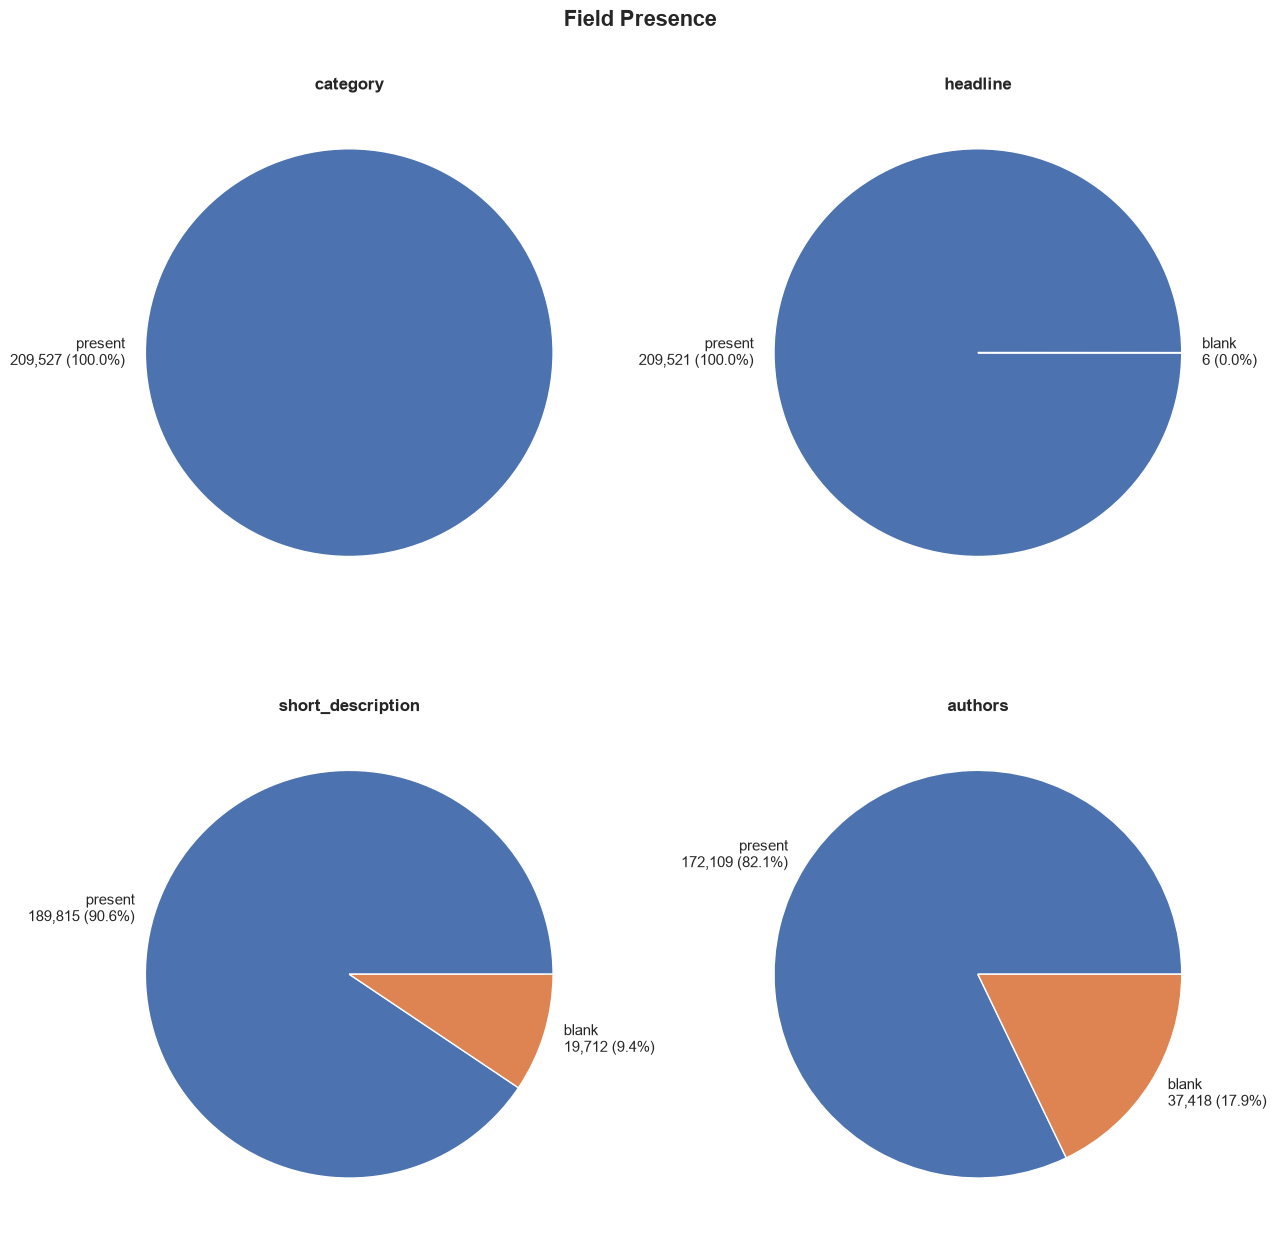

── Both Text Fields Blank ──────────────────


,category,headline,short_description,authors,date,link
90944,POLITICS,,,"Robert Moran, ContributorRobert Moran leads Br...",2015-08-22,https://www.huffingtonpost.com/entry/lincoln-2...
103675,WORLDPOST,,,"Natasha Srdoc, ContributorAuthor, Economist, C...",2015-03-29,https://www.huffingtonpost.com/entry/us-and-eu...
109100,BUSINESS,,,"Gary Snyder, ContributorWriter and Media Strat...",2015-01-25,https://www.huffingtonpost.com/entry/disney-ce...
110153,MEDIA,,,"Gary Snyder, ContributorWriter and Media Strat...",2015-01-13,https://www.huffingtonpost.com/entry/beverly-h...
122145,QUEER VOICES,,,"Gary Snyder, ContributorWriter and Media Strat...",2014-08-28,https://www.huffingtonpost.com/entry/beverly-h...


In [3]:
df_derived = pd.DataFrame(
  {
    "category_wc": df_raw["category"].str.split().str.len(),
    "headline_wc": df_raw["headline"].str.split().str.len(),
    "short_description_wc": df_raw["short_description"].str.split().str.len(),
    "authors_wc": df_raw["authors"].str.split().str.len(),
  }
)
df_derived["both_blank"] = df_derived["headline_wc"].eq(0) & df_derived["short_description_wc"].eq(0)

fig, axes = plt.subplots(2, 2, figsize=(13, 13))
for ax, col in zip(axes.flat, ["category", "headline", "short_description", "authors"]):
  counts = df_derived[f"{col}_wc"].eq(0).value_counts().rename({False: "present", True: "blank"})
  pct = counts / counts.sum() * 100
  labels = [f"{k}\n{n:,} ({p:.1f}%)" for k, n, p in zip(counts.index, counts, pct)]
  counts.plot.pie(ax=ax, ylabel="", title=col, labels=labels)
fig.suptitle("Field Presence")
plt.tight_layout()
plt.show()  # flush the figure first so it renders above the stdout line below

show("Both Text Fields Blank", df_raw[df_derived["both_blank"]].head())

#### **Duplicates**

Finds rows with identical text, and the subset filed under different categories: label noise that caps achievable accuracy.


In [4]:
text_cols = ["headline", "short_description"]
df_sub = df_raw.loc[~df_derived["both_blank"]]

sr_both_dupes = df_sub.duplicated(subset=text_cols, keep=False)
df_dupes = df_sub[sr_both_dupes].sort_values(text_cols)
show("Both Text Fields Duplicate", df_dupes.head())

sr_conflict = df_dupes.groupby(text_cols)["category"].transform("nunique").gt(1)
df_derived["conflict"] = sr_conflict.reindex(df_raw.index, fill_value=False)
show("Category Conflicts", df_dupes[sr_conflict].head())

── Both Text Fields Duplicate ──────────────


,category,headline,short_description,authors,date,link
205535,BLACK VOICES,'Black Love' Wedding Announcements (PHOTOS),"""Black Love"" Wedding Announcements: Getting ma...",Julee Wilson,2012-03-11,https://www.huffingtonpost.com/entry/black-lov...
206846,BLACK VOICES,'Black Love' Wedding Announcements (PHOTOS),"""Black Love"" Wedding Announcements: Getting ma...",Julee Wilson,2012-02-26,https://www.huffingtonpost.com/entry/black-lov...
208219,BLACK VOICES,'Black Love' Wedding Announcements (PHOTOS),"""Black Love"" Wedding Announcements: Getting ma...",Julee Wilson,2012-02-11,https://www.huffingtonpost.com/entry/black-lov...
208789,BLACK VOICES,'Black Love' Wedding Announcements (PHOTOS),"""Black Love"" Wedding Announcements: Getting ma...",Julee Wilson,2012-02-05,https://www.huffingtonpost.com/entry/black-lov...
205026,TRAVEL,'Riding The Dog': Coast-To-Coast By Greyhound Bus,Why would you ride on Greyhound instead of dri...,"Peter Mandel, Contributor\nWashington Post con...",2012-03-16,https://www.huffingtonpost.com/entry/riding-th...
206349,TRAVEL,'Riding The Dog': Coast-To-Coast By Greyhound Bus,Why would you ride on Greyhound instead of dri...,"Peter Mandel, Contributor\nWashington Post con...",2012-03-02,https://www.huffingtonpost.com/entry/riding-th...
200334,STYLE & BEAUTY,"'SNL' Skewers Tanning Mom, Asks Her For Beauty...",It was only a matter of time before the notori...,,2012-05-06,https://www.huffingtonpost.com/entry/snl-tanni...
200335,STYLE & BEAUTY,"'SNL' Skewers Tanning Mom, Asks Her For Beauty...",It was only a matter of time before the notori...,,2012-05-06,https://www.huffingtonpost.com/entry/snl-tanni...
145141,ENVIRONMENT,10 Cities That Could Run Out Of Water - Weathe...,"Securing access to plentiful, renewable source...",,2013-12-15,https://www.huffingtonpost.comhttp://www.weath...
145142,ENVIRONMENT,10 Cities That Could Run Out Of Water - Weathe...,"Securing access to plentiful, renewable source...",,2013-12-15,https://www.huffingtonpost.comhttp://www.weath...


── Category Conflicts ──────────────────────


,category,headline,short_description,authors,date,link
192757,HOME & LIVING,A Conversation With Decorator and Fashion Desi...,Much like the arresting color combinations she...,"Blue Carreon, Contributor\nFashion writer",2012-07-26,https://www.huffingtonpost.com/entry/kelly-wea...
192783,STYLE & BEAUTY,A Conversation With Decorator and Fashion Desi...,Much like the arresting color combinations she...,"Blue Carreon, Contributor\nFashion writer",2012-07-26,https://www.huffingtonpost.com/entry/kelly-wea...
131596,WOMEN,Bring Back Our Girls,,"Jonathan Schmock, ContributorEditorial cartoonist",2014-05-13,https://www.huffingtonpost.com/entry/bring-bac...
132812,IMPACT,Bring Back Our Girls,,"Yvonna Russell, ContributorWriter",2014-04-28,https://www.huffingtonpost.com/entry/bring-bac...
192691,STYLE & BEAUTY,Could You Go a Year Without Buying Anything Ne...,There is one thing that sets me apart from the...,"Katy Wolk-Stanley, Contributor\nBlogger, The N...",2012-07-27,https://www.huffingtonpost.com/entry/saving-mo...
192903,MONEY,Could You Go a Year Without Buying Anything Ne...,There is one thing that sets me apart from the...,"Katy Wolk-Stanley, Contributor\nBlogger, The N...",2012-07-25,https://www.huffingtonpost.com/entry/saving-mo...
102612,IMPACT,Food for Thought,,"Michael Møller , ContributorDirector General o...",2015-04-11,https://www.huffingtonpost.com/entry/food-for-...
102614,TASTE,Food for Thought,,"Michael Møller , ContributorDirector General o...",2015-04-11,https://www.huffingtonpost.com/entry/food-for-...
191536,HOME & LIVING,"Ikea Bag Dress Is Massive, In Need Of A Good S...",Corell's not the first person to turn the icon...,,2012-08-09,https://www.huffingtonpost.com/entry/ikea-bag-...
191556,STYLE & BEAUTY,"Ikea Bag Dress Is Massive, In Need Of A Good S...",Corell's not the first person to turn the icon...,,2012-08-09,https://www.huffingtonpost.com/entry/ikea-bag-...


### **Cleaning**

Three drops:

- **no-text rows** (`both_blank`): nothing for a text model to read.

- **conflicts**: identical text under different categories, with no correct single label.

- **exact duplicates**: identical text and category, deduped to one row.


In [5]:
keep_cols = ["category", "headline", "short_description", "authors", "date"]

df_clean = (
  df_raw[keep_cols]
  .assign(has_author=df_derived["authors_wc"].gt(0))
  .loc[~df_derived["both_blank"] & ~df_derived["conflict"]]
  .drop_duplicates(subset=text_cols + ["category"])
  .reset_index(drop=True)
)
show("Preview (CLEAN)", df_clean.head())

df_summary_clean = df_clean.describe(include="all").T
df_summary_clean.insert(0, "dtype", df_clean.dtypes)
show("Summary (CLEAN)", df_summary_clean.head())

── Preview (CLEAN) ─────────────────────────


,category,headline,short_description,authors,date,has_author
0,U.S. NEWS,Over 4 Million Americans Roll Up Sleeves For O...,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23,True
1,U.S. NEWS,"American Airlines Flyer Charged, Banned For Li...",He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23,True
2,COMEDY,23 Of The Funniest Tweets About Cats And Dogs ...,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23,True
3,PARENTING,The Funniest Tweets From Parents This Week (Se...,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23,True
4,U.S. NEWS,Woman Who Called Cops On Black Bird-Watcher Lo...,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22,True
5,U.S. NEWS,Cleaner Was Dead In Belk Bathroom For 4 Days B...,The 63-year-old woman was seen working at the ...,,2022-09-22,False
6,U.S. NEWS,Reporter Gets Adorable Surprise From Her Boyfr...,"""Who's that behind you?"" an anchor for New Yor...",Elyse Wanshel,2022-09-22,True
7,WORLD NEWS,Puerto Ricans Desperate For Water After Hurric...,More than half a million people remained witho...,"DÁNICA COTO, AP",2022-09-22,True
8,CULTURE & ARTS,How A New Documentary Captures The Complexity ...,"In ""Mija,"" director Isabel Castro combined mus...",Marina Fang,2022-09-22,True
9,WORLD NEWS,Biden At UN To Call Russian War An Affront To ...,White House officials say the crux of the pres...,"Aamer Madhani, AP",2022-09-21,True


── Summary (CLEAN) ─────────────────────────


,dtype,count,unique,top,freq,mean,min,25%,50%,75%,max
category,str,209023,42,POLITICS,35582,NaN,NaN,NaN,NaN,NaN,NaN
headline,str,209023,207984,Sunday Roundup,90,NaN,NaN,NaN,NaN,NaN,NaN
short_description,str,209023,187012,,19606,NaN,NaN,NaN,NaN,NaN,NaN
authors,str,209023,29163,,37309,NaN,NaN,NaN,NaN,NaN,NaN
date,datetime64[us],209023,NaN,NaN,NaN,2015-05-01 01:13:44.102611,2012-01-28 00:00:00,2013-08-11 00:00:00,2015-03-18 00:00:00,2016-11-02 00:00:00,2022-09-23 00:00:00
has_author,bool,209023,2,True,171714,NaN,NaN,NaN,NaN,NaN,NaN


### **Output**

#### **Train / Test Split**

The stratified train/test split, so every category appears on both sides. Written to base/.


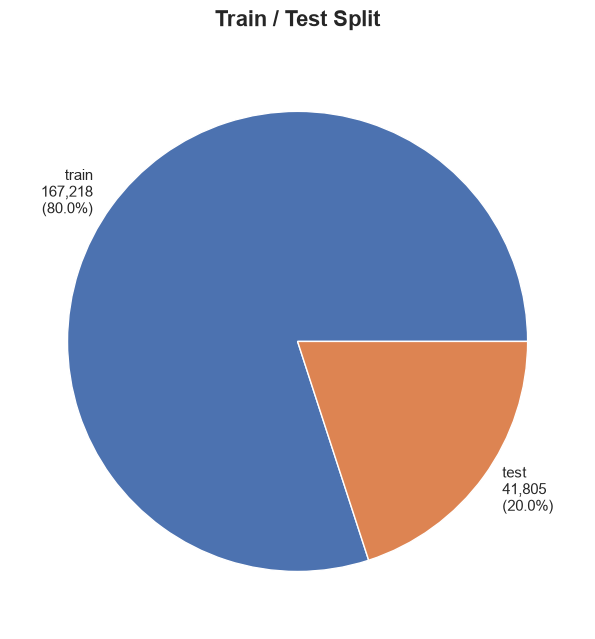

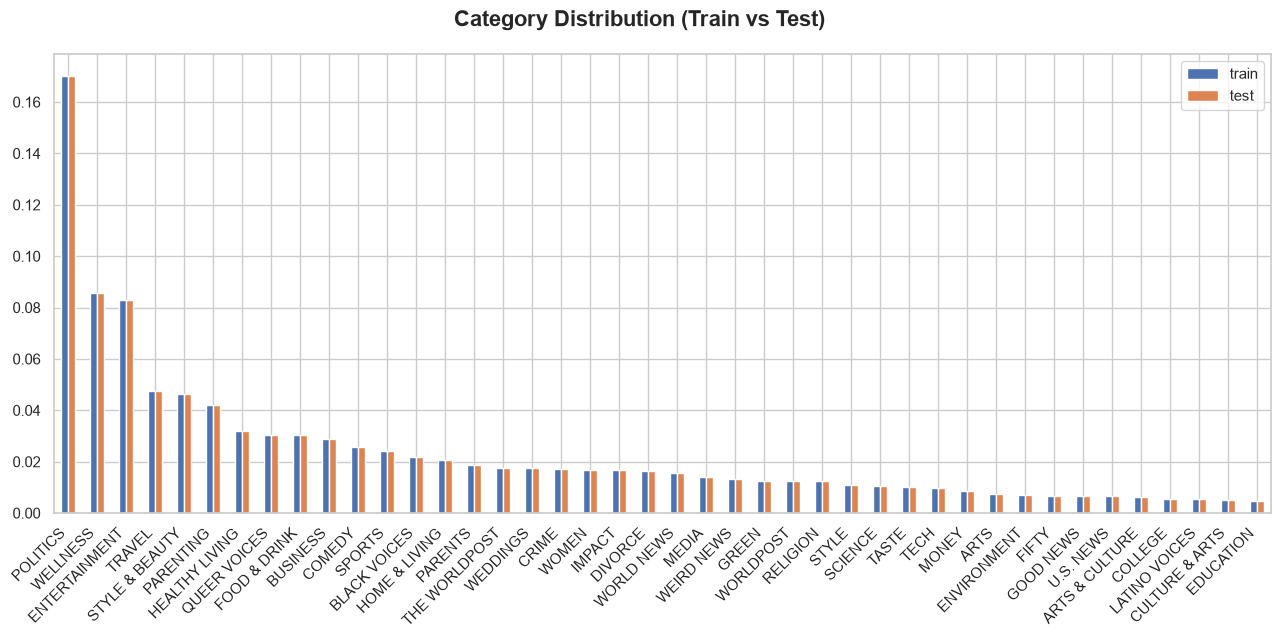

In [6]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(
  df_clean,
  test_size=TEST_SIZE,
  stratify=df_clean["category"],
  random_state=RANDOM_STATE,
)

df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

df_train.to_parquet(DIR_BASE / "train.parquet", index=False)
df_test.to_parquet(DIR_BASE / "test.parquet", index=False)

sizes = pd.Series({"train": len(df_train), "test": len(df_test)})
labels = [f"{k}\n{v:,}\n({v / sizes.sum():.1%})" for k, v in sizes.items()]
sizes.plot.pie(figsize=(6.5, 6.5), ylabel="", labels=labels)
plt.suptitle("Train / Test Split")
plt.tight_layout()

df_proportions = pd.concat(
  {
    "train": df_train["category"].value_counts(normalize=True),
    "test": df_test["category"].value_counts(normalize=True),
  },
  axis=1,
).sort_values("train", ascending=False)
df_proportions.plot.bar(figsize=(13, 6.5), xlabel="")
plt.xticks(rotation=45, ha="right")
plt.suptitle("Category Distribution (Train vs Test)")
plt.tight_layout()

#### **Categories**

The full raw category list, for merge-dict validation and mapping to merged versions later.


In [7]:
import json
import numpy as np

categories = sorted(df_clean["category"].unique().tolist())
with open(DIR_BASE / "labels.json", "w") as f:
  json.dump(categories, f, indent=2)
show("Categories", np.array2string(np.array(categories), max_line_width=100, separator=", "))

── Categories ──────────────────────────────
['ARTS', 'ARTS & CULTURE', 'BLACK VOICES', 'BUSINESS', 'COLLEGE', 'COMEDY', 'CRIME',
 'CULTURE & ARTS', 'DIVORCE', 'EDUCATION', 'ENTERTAINMENT', 'ENVIRONMENT', 'FIFTY', 'FOOD & DRINK',
 'GOOD NEWS', 'GREEN', 'HEALTHY LIVING', 'HOME & LIVING', 'IMPACT', 'LATINO VOICES', 'MEDIA',
 'MONEY', 'PARENTING', 'PARENTS', 'POLITICS', 'QUEER VOICES', 'RELIGION', 'SCIENCE', 'SPORTS',
 'STYLE', 'STYLE & BEAUTY', 'TASTE', 'TECH', 'THE WORLDPOST', 'TRAVEL', 'U.S. NEWS', 'WEDDINGS',
 'WEIRD NEWS', 'WELLNESS', 'WOMEN', 'WORLD NEWS', 'WORLDPOST']
